In [ ]:
 # ##### Exploratory Data Analysis
# Data cleaning is the process of preparing data for analysis by removing or modifying data 
# that is incorrect, incomplete, irrelevant, duplicated, or improperly formatted.

In [ ]:
# Build a model to predict performance of employees, 
# based on the visualisation and analysis of past data of employee performance

In [1]:
# Import packages 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split



In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# from sklearn.impute import SimpleImputer

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

In [116]:
# Read your data from CSV to a dataframe using Pandas
df = pd.read_csv("Employee_performance_prediction.csv")

In [9]:
# Take a closer look at the data using the str() and head() functions and check if the data got imported properly
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70


In [10]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [11]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70
23489,5973,Technology,region_17,Master's & above,m,other,3,40,5.0,5,1,0,89


In [12]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [13]:
df.shape

(23490, 13)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [117]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

employee_id               int64
department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

In [19]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [20]:
df.describe(include="object")

,department,region,education,gender,recruitment_channel
count,23490,23490,22456,23490,23490
unique,9,34,3,2,3
top,Sales & Marketing,region_2,Bachelor's,m,other
freq,7315,5299,15578,16596,13078


In [21]:
# Check missing / null values

In [24]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [32]:
missing_val = df.isnull().sum()
# missing_val
missing_val_per=((missing_val/len(df))* 100).sort_values(ascending=False)
missing_val_per

previous_year_rating    7.713921
education               4.401873
employee_id             0.000000
department              0.000000
region                  0.000000
gender                  0.000000
recruitment_channel     0.000000
no_of_trainings         0.000000
age                     0.000000
length_of_service       0.000000
KPIs_met >80%           0.000000
awards_won?             0.000000
avg_training_score      0.000000
dtype: float64

In [33]:
# check duplicates
df["employee_id"].duplicated().sum()

np.int64(0)

In [43]:
# no. of numeric columns
numeric_col = df.select_dtypes(exclude="object").columns
numeric_col

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [40]:
df.describe().count()

employee_id             8
no_of_trainings         8
age                     8
previous_year_rating    8
length_of_service       8
KPIs_met >80%           8
awards_won?             8
avg_training_score      8
dtype: int64

In [42]:
categoric_col = df.select_dtypes(include="object").columns
categoric_col

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [52]:
# Analyze each categorical variable
# business/analysis question

In [44]:
df.describe(include="object").count()

department             4
region                 4
education              4
gender                 4
recruitment_channel    4
dtype: int64

In [47]:
df["department"].value_counts() 

department
Sales & Marketing    7315
Operations           4764
Procurement          3020
Technology           3011
Analytics            2319
Finance              1091
HR                   1085
Legal                 445
R&D                   440
Name: count, dtype: int64

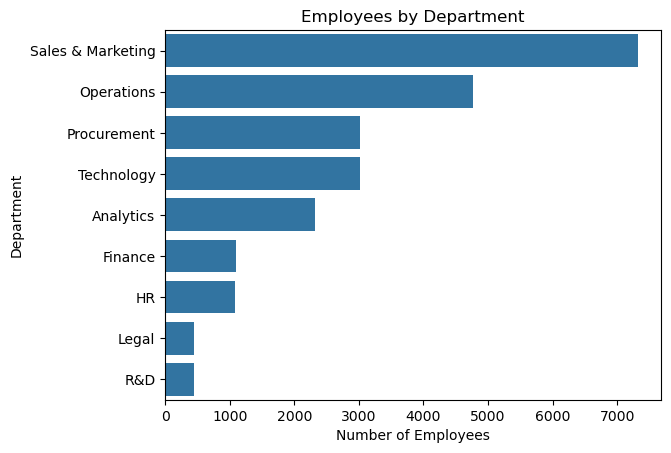

In [59]:
# Which department has the highest and lowest number of employees? ------> count no. of emp in each dept

sns.countplot(data=df,y="department",order=df["department"].value_counts().index)
plt.title("Employees by Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.show()

In [48]:
df["region"].value_counts()

region
region_2     5299
region_22    2739
region_7     1982
region_13    1167
region_15    1130
region_26    1011
region_31     844
region_4      775
region_27     710
region_28     595
region_16     590
region_11     571
region_23     516
region_32     433
region_29     414
region_19     410
region_17     361
region_14     350
region_5      342
region_25     337
region_20     326
region_6      298
region_30     273
region_8      269
region_10     269
region_1      238
region_24     219
region_12     215
region_9      180
region_21     179
region_34     155
region_3      147
region_33     126
region_18      20
Name: count, dtype: int64

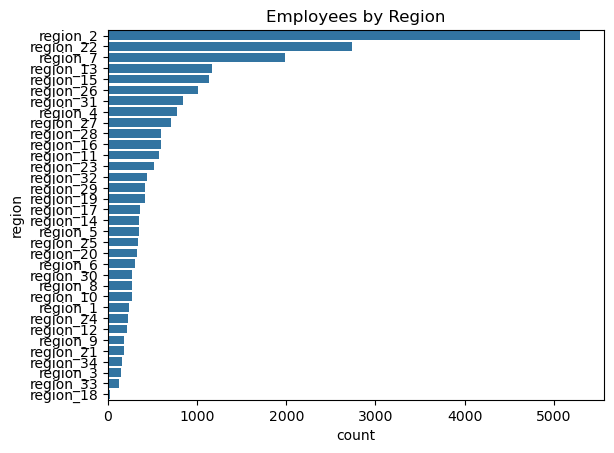

In [73]:
# Which regions have the highest and lowest number of employees?

sns.countplot(
    data=df,
    y="region"
, order=df["region"].value_counts().index)
plt.title("Employees by Region")

plt.show()

In [49]:
df["education"].value_counts()

education
Bachelor's          15578
Master's & above     6504
Below Secondary       374
Name: count, dtype: int64

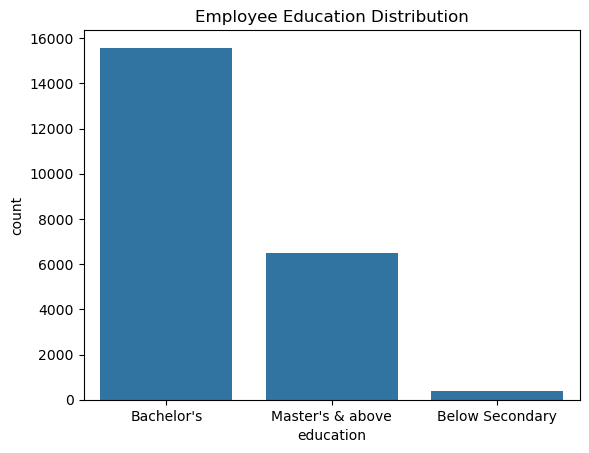

In [64]:
# What is the educational qualification distribution of employees?

sns.countplot(data=df,x="education")

plt.title("Employee Education Distribution")

plt.show()

In [50]:
df["gender"].value_counts()

gender
m    16596
f     6894
Name: count, dtype: int64

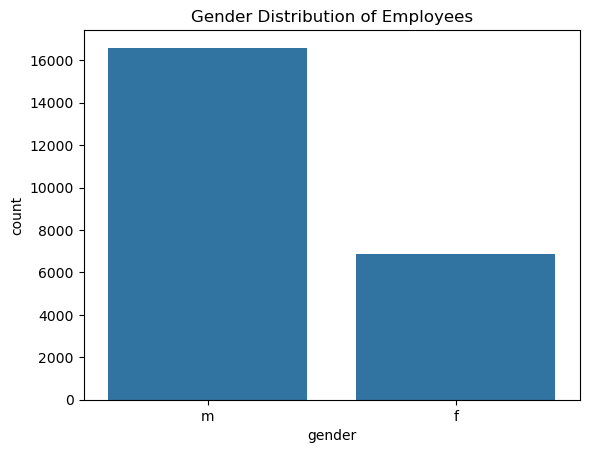

In [60]:
# What is the gender distribution of employees?
sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution of Employees")
plt.show()

In [51]:
df["recruitment_channel"].value_counts()

recruitment_channel
other       13078
sourcing     9961
referred      451
Name: count, dtype: int64

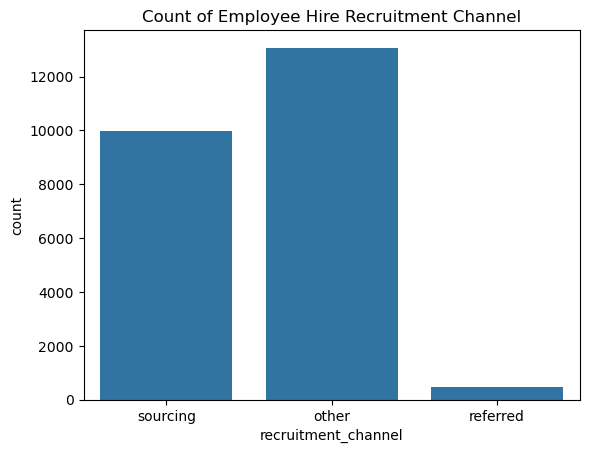

In [72]:
# Which recruitment channel is used most frequently to hire employees?
sns.countplot(
    data=df,
    x="recruitment_channel"
)
plt.title("Count of Employee Hire Recruitment Channel")
plt.show()

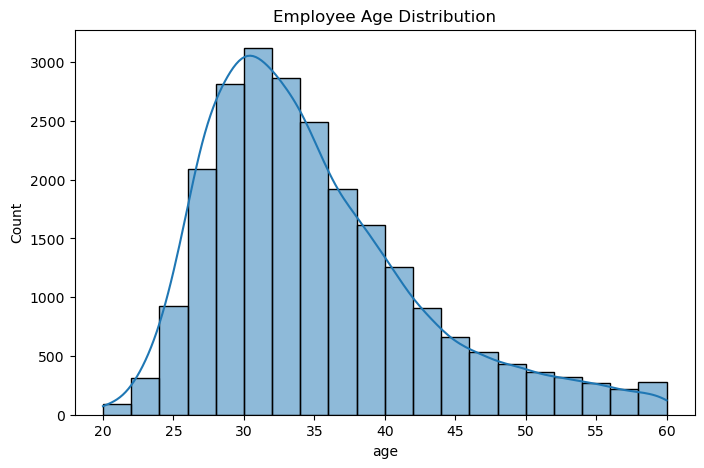

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Employee Age Distribution")

plt.show()

In [75]:
# Analyze previous-year rating
df["previous_year_rating"].value_counts().sort_index()

previous_year_rating
1.0    2680
2.0    1731
3.0    7921
4.0    4249
5.0    5097
Name: count, dtype: int64

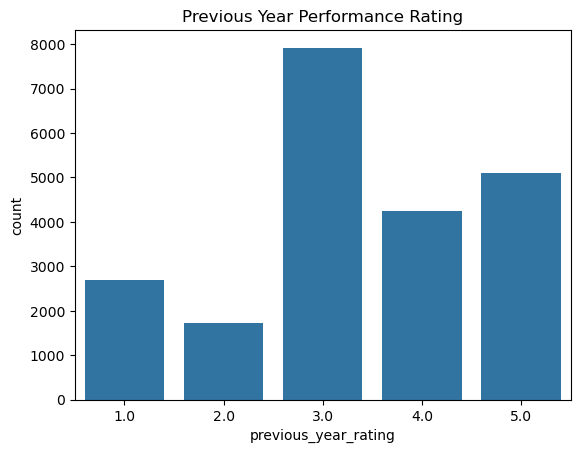

In [76]:
sns.countplot(data=df,x="previous_year_rating")
plt.title("Previous Year Performance Rating")
plt.show()

In [77]:
# Analyze KPI performance

df["KPIs_met >80%"].value_counts()

KPIs_met >80%
0    15061
1     8429
Name: count, dtype: int64

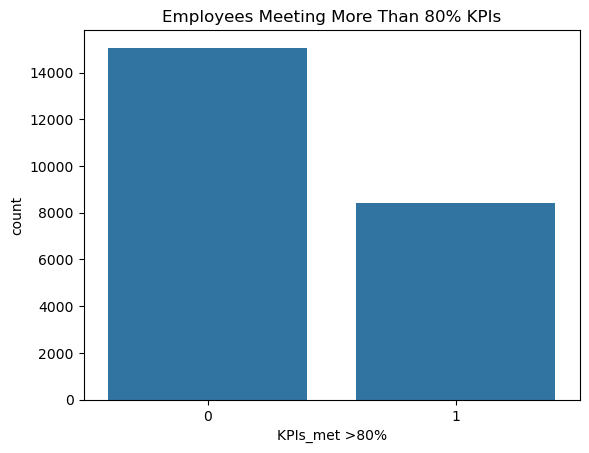

In [78]:
sns.countplot(data=df,x="KPIs_met >80%")

plt.title("Employees Meeting More Than 80% KPIs")

plt.show()

In [79]:
# Analyze awards
df["awards_won?"].value_counts()

awards_won?
0    22955
1      535
Name: count, dtype: int64

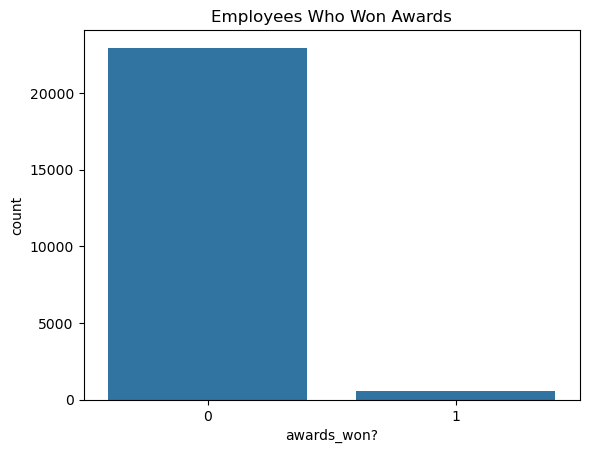

In [80]:
sns.countplot(data=df,x="awards_won?")

plt.title("Employees Who Won Awards")

plt.show()

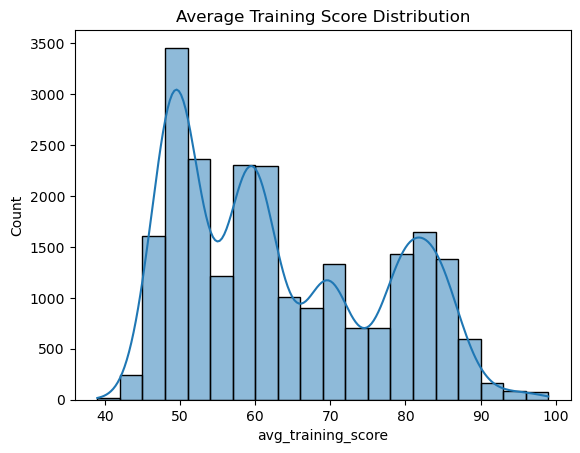

In [81]:
# Analyze training score
sns.histplot(data=df, x="avg_training_score", bins=20, kde=True)

plt.title("Average Training Score Distribution")

plt.show()

In [88]:
# df["avg_training_score"].value_counts().sum()

In [82]:
df["avg_training_score"].describe()

count    23490.000000
mean        63.263133
std         13.411750
min         39.000000
25%         51.000000
50%         60.000000
75%         76.000000
max         99.000000
Name: avg_training_score, dtype: float64

In [126]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70


In [91]:
# Correlation analysis
# df.drop(columns=["employee_id"]).select_dtypes(include=np.number)

In [90]:
numeric_col_df = df.drop(columns=["employee_id"]).select_dtypes(include=np.number)
numeric_col_df

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,1,24,NaN,1,1,0,77
1,1,31,3.0,5,0,0,51
2,1,31,1.0,4,0,0,47
3,3,31,2.0,9,0,0,65
4,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...
23485,1,24,3.0,1,0,0,61
23486,1,31,3.0,7,0,0,74
23487,1,26,4.0,4,0,0,50
23488,3,27,NaN,1,0,0,70


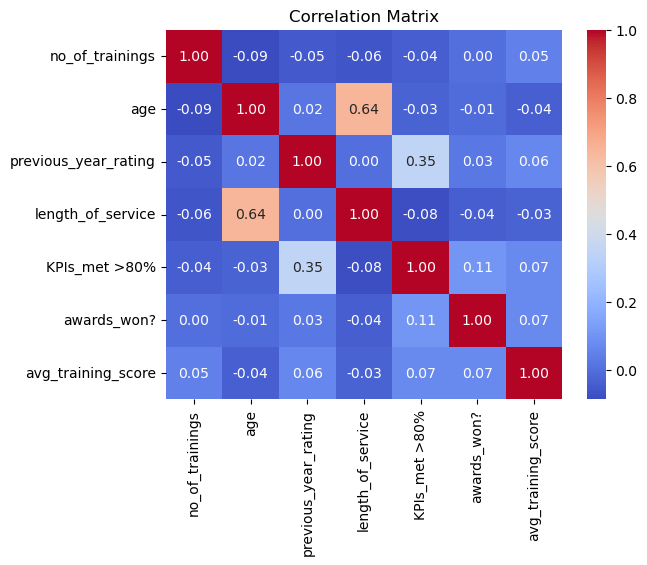

In [93]:

sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [121]:
# Check missing values
print(df.isnull().sum())

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [122]:
missing_val = df.isnull().sum()
# missing_val
missing_val_per=((missing_val/len(df))* 100).sort_values(ascending=False)
missing_val_per

previous_year_rating    7.713921
education               4.401873
employee_id             0.000000
department              0.000000
region                  0.000000
gender                  0.000000
recruitment_channel     0.000000
no_of_trainings         0.000000
age                     0.000000
length_of_service       0.000000
KPIs_met >80%           0.000000
awards_won?             0.000000
avg_training_score      0.000000
dtype: float64

In [101]:
df["education"].value_counts(dropna=False)

education
Bachelor's          15578
Master's & above     6504
NaN                  1034
Below Secondary       374
Name: count, dtype: int64

In [123]:
df["education"] = df["education"].fillna("Unknown")

In [124]:
df["education"]

0              Bachelor's
1              Bachelor's
2              Bachelor's
3              Bachelor's
4              Bachelor's
               ...       
23485     Below Secondary
23486          Bachelor's
23487          Bachelor's
23488          Bachelor's
23489    Master's & above
Name: education, Length: 23490, dtype: object

In [106]:
df["education"].isnull().sum()

np.int64(0)

In [107]:
df["previous_year_rating"].value_counts(dropna=False).sort_index()

previous_year_rating
1.0    2680
2.0    1731
3.0    7921
4.0    4249
5.0    5097
NaN    1812
Name: count, dtype: int64

In [118]:
# df["previous_year_rating"]=
# df["previous_year_rating"].fillna(df["previous_year_rating"].median(),inplace=True)

In [119]:
# df["previous_year_rating"] = 
# df["previous_year_rating"].fillna(0)

In [120]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [132]:
df["previous_year_rating"]

0        NaN
1        3.0
2        1.0
3        2.0
4        4.0
        ... 
23485    3.0
23486    3.0
23487    4.0
23488    NaN
23489    5.0
Name: previous_year_rating, Length: 23490, dtype: float64

In [133]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,previous_year_rating_missing
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77,1
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51,0
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47,0
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65,0
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61,0
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74,0
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50,0
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70,1


In [115]:
# df.isnull().sum().sum()

np.int64(0)

In [138]:
# df[df.isna().any(axis=1)]

In [131]:
(df["previous_year_rating"].isnull().astype(int))

0        1
1        0
2        0
3        0
4        0
        ..
23485    0
23486    0
23487    0
23488    1
23489    0
Name: previous_year_rating, Length: 23490, dtype: int64

In [136]:
df["previous_year_rating"]=df["previous_year_rating"].fillna(0.0)

In [137]:
df["previous_year_rating"]

0        0.0
1        3.0
2        1.0
3        2.0
4        4.0
        ... 
23485    3.0
23486    3.0
23487    4.0
23488    0.0
23489    5.0
Name: previous_year_rating, Length: 23490, dtype: float64

In [139]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,previous_year_rating_missing
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,0.0,1,1,0,77,1
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51,0
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47,0
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65,0
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61,0
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74,0
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50,0
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,0.0,1,0,0,70,1
